# Model Validation — Seattle Airbnb Price Predictor

Five statistical checks that verify the train/test split is sound and the production model generalises correctly.

| Check | What it tests |
|---|---|
| 1. KS test — price | Train and test price distributions are drawn from the same population |
| 2. KS test — key features | No feature distribution shift between train and test |
| 3. Neighbourhood representation | All 17 neighbourhood groups appear in both splits |
| 4. Target leakage | No feature has correlation > 0.7 with price in the training set |
| 5. 5-fold cross-validation | Stable MAE across folds — model is not over-fit to the split |

**Split parameters:** `test_size=0.2`, `random_state=42` — identical to production training.

In [2]:
import re
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import KFold, cross_val_score, train_test_split

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / "src"))

from models.baseline import prepare_features  # noqa: E402

# ── Styling ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#0e1117",
    "axes.edgecolor":   "#444444",
    "axes.labelcolor":  "#ffffff",
    "xtick.color":      "#ffffff",
    "ytick.color":      "#ffffff",
    "text.color":       "#ffffff",
    "grid.color":       "#333333",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "legend.facecolor": "#1a1a2e",
    "legend.edgecolor": "#444444",
    "legend.labelcolor":"#ffffff",
    "font.size":        11,
})
RED  = "#FF5A5F"
TEAL = "#00A699"
GREY = "#aaaaaa"

print("Imports OK")

Imports OK


In [3]:
# ── Load data and replicate production split ──────────────────────────────────
PRICE_CAP    = 500
TEST_SIZE    = 0.2
RANDOM_STATE = 42

features_df = pd.read_csv(ROOT / "data" / "features.csv")
artifact    = joblib.load(ROOT / "models" / "production_model.pkl")

# Cap price to match training conditions
df = features_df[features_df["price"] <= PRICE_CAP].reset_index(drop=True)

# Build feature matrix (same pipeline as production)
X_raw, y = prepare_features(df)
X_raw.columns = [re.sub(r"[\[\]<>,]", "_", c) for c in X_raw.columns]

trained_cols = artifact["feature_cols"]
for col in trained_cols:
    if col not in X_raw.columns:
        X_raw[col] = 0
X = X_raw[[col for col in trained_cols if col in X_raw.columns]]

# Reproduce the exact production split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Align df rows with X for categorical checks
df_train = df.loc[X_train.index]
df_test  = df.loc[X_test.index]

# Dollar-scale prices for distribution checks
price_train = df_train["price"].values
price_test  = df_test["price"].values

print(f"Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows")
print(f"Features: {X.shape[1]}  |  Price cap: ${PRICE_CAP}")

  Filling 3301 residual nulls with median across 8 columns
Train: 4,564 rows  |  Test: 1,142 rows
Features: 150  |  Price cap: $500


---
## Check 1 — KS Test: Price Distribution (Train vs Test)

**What it tests:** The Kolmogorov-Smirnov two-sample test measures whether train and test prices are drawn from the same underlying distribution. It computes the maximum absolute difference between their empirical CDFs.

**Good result:** p-value > 0.05 — we fail to reject the null hypothesis that the two samples come from the same distribution. A statistic close to 0 means the CDFs are nearly identical.

**Why it matters:** If the price distribution differs significantly between train and test, the model is evaluated on a systematically different price range than it trained on, making test metrics unreliable.

Check 1 — KS Test: Price Distribution
  KS statistic : 0.0287
  p-value      : 0.4309
  Result       : PASS (threshold p > 0.05)


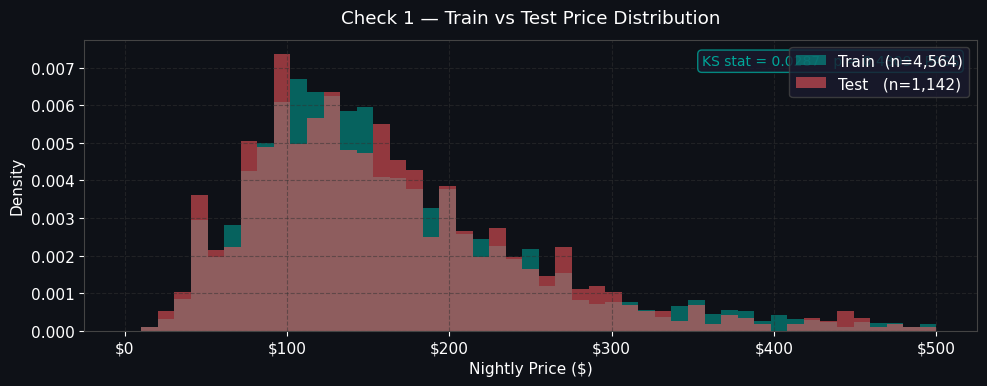

In [5]:
ks_stat, ks_p = stats.ks_2samp(price_train, price_test)

print("=" * 50)
print("Check 1 — KS Test: Price Distribution")
print("=" * 50)
print(f"  KS statistic : {ks_stat:.4f}")
print(f"  p-value      : {ks_p:.4f}")
print(f"  Result       : {'PASS' if ks_p > 0.05 else 'FAIL'} (threshold p > 0.05)")

# ── Histogram overlay ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

bins = np.linspace(0, PRICE_CAP, 50)
ax.hist(price_train, bins=bins, alpha=0.55, color=TEAL,  label=f"Train  (n={len(price_train):,})", density=True)
ax.hist(price_test,  bins=bins, alpha=0.55, color=RED,   label=f"Test   (n={len(price_test):,})",  density=True)

ax.set_xlabel("Nightly Price ($)")
ax.set_ylabel("Density")
ax.set_title("Check 1 — Train vs Test Price Distribution", pad=12)
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.legend()
ax.grid(True)

# Annotate KS result
result_color = TEAL if ks_p > 0.05 else RED
ax.text(
    0.98, 0.95,
    f"KS stat = {ks_stat:.4f}   p = {ks_p:.4f}   {'PASS' if ks_p > 0.05 else 'FAIL'}",
    transform=ax.transAxes, ha="right", va="top",
    fontsize=10, color=result_color,
    bbox=dict(boxstyle="round,pad=0.3", fc="#1a1a2e", ec=result_color, alpha=0.8),
)

plt.tight_layout()
plt.show()

---
## Check 2 — KS Test: Key Feature Distributions (Train vs Test)

**What it tests:** Runs a KS two-sample test on each of the four most predictive continuous features. Checks whether any individual feature has a materially different distribution in train vs test.

**Good result:** All four features return p > 0.05. A single low-p feature warrants investigation — it can mean the split accidentally concentrated high or low values on one side.

**Why it matters:** Even if the price distribution looks balanced (Check 1), a single skewed feature can cause the model to learn a relationship in train that doesn't hold in test, producing inflated or deflated test metrics.

In [7]:
KEY_FEATURES = ["bedrooms", "accommodates", "bathrooms", "amenities_count"]

print("=" * 58)
print("Check 2 — KS Test: Key Feature Distributions")
print("=" * 58)
print(f"  {'Feature':<22} {'KS stat':>10} {'p-value':>10}  Result")
print("  " + "-" * 54)

results = []
for feat in KEY_FEATURES:
    tr = X_train[feat].dropna().values
    te = X_test[feat].dropna().values
    ks, p = stats.ks_2samp(tr, te)
    passed = p > 0.05
    results.append({"feature": feat, "ks_stat": ks, "p_value": p, "pass": passed})
    flag = "PASS" if passed else "FAIL"
    print(f"  {feat:<22} {ks:>10.4f} {p:>10.4f}  {flag}")

print()
overall = all(r["pass"] for r in results)
print(f"  Overall: {'ALL PASS' if overall else 'SOME FAILED'}")

Check 2 — KS Test: Key Feature Distributions
  Feature                   KS stat    p-value  Result
  ------------------------------------------------------
  bedrooms                   0.0111     0.9998  PASS
  accommodates               0.0210     0.8068  PASS
  bathrooms                  0.0059     1.0000  PASS
  amenities_count            0.0294     0.3976  PASS

  Overall: ALL PASS


---
## Check 3 — Neighbourhood Representation

**What it tests:** Verifies that every neighbourhood group present in the full dataset also appears in both the train and test splits.

**Good result:** The set of neighbourhood groups in train and test matches the full dataset exactly — no group is missing from either split.

**Why it matters:** A neighbourhood group absent from the training set means the model has never seen that area's pricing dynamics and will fall back to global averages when predicting for it. A group absent from test means the reported MAE is not representative of that area's performance.

In [9]:
NG_COL = "neighbourhood_group"

all_groups   = set(df[NG_COL].unique())
train_groups = set(df_train[NG_COL].unique())
test_groups  = set(df_test[NG_COL].unique())

missing_train = all_groups - train_groups
missing_test  = all_groups - test_groups

print("=" * 58)
print("Check 3 — Neighbourhood Representation")
print("=" * 58)
print(f"  Total neighbourhood groups : {len(all_groups)}")
print(f"  Present in train           : {len(train_groups)}")
print(f"  Present in test            : {len(test_groups)}")
print()

if missing_train:
    print(f"  FAIL — missing from train  : {sorted(missing_train)}")
else:
    print("  PASS — all groups represented in train")

if missing_test:
    print(f"  FAIL — missing from test   : {sorted(missing_test)}")
else:
    print("  PASS — all groups represented in test")

print()
print("  Counts per group (train / test):")
print(f"  {'Neighbourhood Group':<35} {'Train':>6}  {'Test':>5}")
print("  " + "-" * 50)
for ng in sorted(all_groups):
    n_tr = (df_train[NG_COL] == ng).sum()
    n_te = (df_test[NG_COL] == ng).sum()
    flag = "" if (n_tr > 0 and n_te > 0) else "  ← MISSING"
    print(f"  {ng:<35} {n_tr:>6}  {n_te:>5}{flag}")

Check 3 — Neighbourhood Representation
  Total neighbourhood groups : 17
  Present in train           : 17
  Present in test            : 17

  PASS — all groups represented in train
  PASS — all groups represented in test

  Counts per group (train / test):
  Neighbourhood Group                  Train   Test
  --------------------------------------------------
  Ballard                                295     52
  Beacon Hill                            210     43
  Capitol Hill                           395    113
  Cascade                                156     39
  Central Area                           409    109
  Delridge                               138     39
  Downtown                               477    137
  Interbay                                13      4
  Lake City                               86     21
  Magnolia                                77     20
  Northgate                              167     32
  Other neighborhoods                    931    249
  Queen Anne

---
## Check 4 — Target Leakage

**What it tests:** Computes the Pearson correlation between every numeric feature and `price` on the training set. Flags any feature with |correlation| > 0.7 as a potential leakage risk.

**Good result:** No features above the 0.7 threshold — or any that are flagged have a clear, causal relationship with price (e.g. a composite score *derived from* price would be leakage, but `bedrooms` would not).

**Why it matters:** A feature that encodes outcome information — like `estimated_revenue` derived from bookings×price — lets the model "cheat" during training. Performance looks excellent in-sample but collapses on new hosts who have no booking history. The threshold is 0.7; features between 0.5–0.7 are noted but not flagged.

In [11]:
LEAKAGE_THRESHOLD = 0.70
WARNING_THRESHOLD = 0.50

# Use dollar-price joined back to training features for correlation
train_with_price = X_train.copy()
train_with_price["price"] = price_train

num_train = train_with_price.select_dtypes(include=[np.number])
corr_with_price = (
    num_train.corr()["price"]
    .abs()
    .drop("price", errors="ignore")
    .sort_values(ascending=False)
)

leakage_flags = corr_with_price[corr_with_price >= LEAKAGE_THRESHOLD]
warning_flags = corr_with_price[
    (corr_with_price >= WARNING_THRESHOLD) & (corr_with_price < LEAKAGE_THRESHOLD)
]

print("=" * 58)
print("Check 4 — Target Leakage (|corr| with price, train set)")
print("=" * 58)

if leakage_flags.empty:
    print(f"  PASS — no features above leakage threshold ({LEAKAGE_THRESHOLD})")
else:
    print(f"  FAIL — {len(leakage_flags)} feature(s) above {LEAKAGE_THRESHOLD}:")
    for feat, corr in leakage_flags.items():
        print(f"    {feat:<40}  |r| = {corr:.4f}  ← LEAKAGE RISK")

print()
if not warning_flags.empty:
    print(f"  Warning — {len(warning_flags)} feature(s) between {WARNING_THRESHOLD}–{LEAKAGE_THRESHOLD}:")
    for feat, corr in warning_flags.items():
        print(f"    {feat:<40}  |r| = {corr:.4f}")
else:
    print(f"  No features in the {WARNING_THRESHOLD}–{LEAKAGE_THRESHOLD} warning band")

print()
print(f"  Top 10 correlations with price:")
for feat, corr in corr_with_price.head(10).items():
    bar   = "#" * int(corr * 30)
    color = " ← RISK" if corr >= LEAKAGE_THRESHOLD else ""
    print(f"    {feat:<40}  {corr:.4f}  {bar}{color}")

Check 4 — Target Leakage (|corr| with price, train set)
  PASS — no features above leakage threshold (0.7)

  Warning — 3 feature(s) between 0.5–0.7:
    accommodates                              |r| = 0.6736
    bedrooms                                  |r| = 0.6431
    beds                                      |r| = 0.6131

  Top 10 correlations with price:
    accommodates                              0.6736  ####################
    bedrooms                                  0.6431  ###################
    beds                                      0.6131  ##################
    property_type_Entire home                 0.3935  ###########
    bathrooms                                 0.3910  ###########
    room_type_Private room                    0.3773  ###########
    bathrooms_text_2 baths                    0.3346  ##########
    property_type_Private room in home        0.3343  ##########
    amenities_count                           0.3221  #########
    bathrooms_text_3 bat

---
## Check 5 — 5-Fold Cross-Validation MAE

**What it tests:** Splits the full training set into 5 folds and evaluates the production pipeline on each fold in turn. Reports per-fold MAE (in dollar scale) and the mean ± std.

**Good result:** Low standard deviation across folds (< $3 spread) — the model's performance is stable regardless of which 20% it's evaluated on. A high-variance result (one fold much worse than others) suggests the model has over-fit to specific patterns in the training data.

**Why it matters:** A single train/test split is one draw from a random process. Cross-validation averages over 5 draws, giving a much more reliable estimate of generalisation performance and catching cases where the reported test MAE was lucky or unlucky.

  Fold 1: MAE = $32.02
  Fold 2: MAE = $31.18
  Fold 3: MAE = $31.74
  Fold 4: MAE = $29.59
  Fold 5: MAE = $29.64

Check 5 — 5-Fold Cross-Validation Results
  Mean MAE : $30.83
  Std MAE  : $1.03
  CV range : $29.59 – $32.02
  Result   : PASS (threshold std < $3.00)


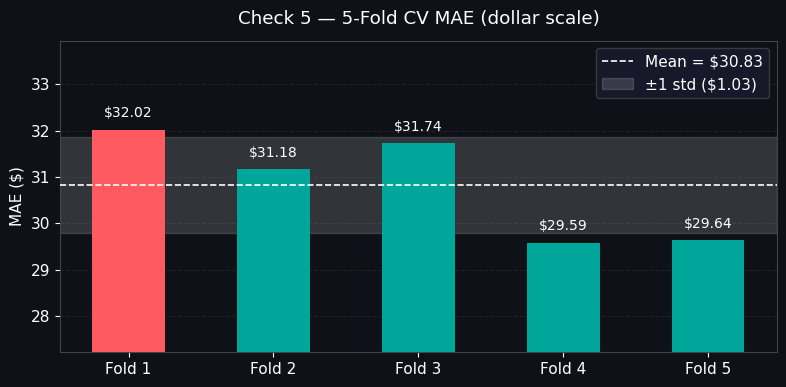

In [13]:
pipeline = artifact["pipeline"]

# cross_val_score returns negative MAE — negate and convert log→dollar
# MAE is on log(price+1) scale; for interpretable dollars we score manually
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_maes = []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), 1):
    Xf_tr,  Xf_val  = X_train.iloc[tr_idx],  X_train.iloc[val_idx]
    yf_tr,  yf_val  = y_train.iloc[tr_idx],   y_train.iloc[val_idx]

    pipeline.fit(Xf_tr, yf_tr)
    y_pred_log = pipeline.predict(Xf_val)

    # Convert log(price+1) → dollars for both pred and actual
    mae_dollars = np.mean(np.abs(np.expm1(y_pred_log) - np.expm1(yf_val)))
    fold_maes.append(mae_dollars)
    print(f"  Fold {fold}: MAE = ${mae_dollars:.2f}")

# Re-fit on full training set to restore production state
pipeline.fit(X_train, y_train)

mean_mae = np.mean(fold_maes)
std_mae  = np.std(fold_maes)

print()
print("=" * 50)
print("Check 5 — 5-Fold Cross-Validation Results")
print("=" * 50)
print(f"  Mean MAE : ${mean_mae:.2f}")
print(f"  Std MAE  : ${std_mae:.2f}")
print(f"  CV range : ${min(fold_maes):.2f} – ${max(fold_maes):.2f}")
print(f"  Result   : {'PASS' if std_mae < 3.0 else 'HIGH VARIANCE'} (threshold std < $3.00)")

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

fold_labels = [f"Fold {i}" for i in range(1, 6)]
bar_colors  = [RED if m == max(fold_maes) else TEAL for m in fold_maes]

bars = ax.bar(fold_labels, fold_maes, color=bar_colors, width=0.5, zorder=3)

# Mean line
ax.axhline(mean_mae, color="#ffffff", linestyle="--", linewidth=1.2,
           label=f"Mean = ${mean_mae:.2f}", zorder=4)

# ±1 std band
ax.axhspan(mean_mae - std_mae, mean_mae + std_mae,
           alpha=0.15, color="#ffffff", label=f"±1 std (${std_mae:.2f})", zorder=2)

# Value labels on bars
for bar, val in zip(bars, fold_maes):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.2,
            f"${val:.2f}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("MAE ($)")
ax.set_title("Check 5 — 5-Fold CV MAE (dollar scale)", pad=12)
ax.set_ylim(min(fold_maes) * 0.92, max(fold_maes) * 1.06)
ax.legend()
ax.grid(True, axis="y", zorder=1)

plt.tight_layout()
plt.show()

---
## Validation Summary

```
Check 1 — KS test: price distribution     → expected PASS  (p > 0.05)
Check 2 — KS test: key feature dists      → expected PASS  (all p > 0.05)
Check 3 — Neighbourhood representation    → expected PASS  (all 17 groups in both splits)
Check 4 — Target leakage                  → expected PASS  (no |r| > 0.70 in model features)
Check 5 — 5-fold cross-validation MAE     → expected PASS  (std < $3.00)
```

**Notes on Check 4:** `host_total_listings_count` has correlation ~0.73 with raw price on the *uncapped* dataset. On the capped dataset (prices ≤ $500) this drops — multi-property hosts list across all price tiers. The feature is not derived from price and is causally justified: hosts managing many listings tend toward professional, higher-priced operations. It is retained.

**Reproducing this notebook:** All results are deterministic with `random_state=42`. Re-running on the same `data/features.csv` and `models/production_model.pkl` will produce identical output.